# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Arhxmz/Flyrank-Internship-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Which published client pages are experiencing significant organic traffic decline and should be prioritized for a content refresh this month?

The decision this supports: Determining which top 10–20% of declining pages get queued for editorial review, versus which stable or growing pages are left untouched — editors have limited bandwidth, so this ranks where that time goes first.

Who acts on it: An SEO editor, who reviews the flagged page, updates outdated facts, improves content depth, and re-optimizes on-page elements.

Cost of a wrong call: A false positive (flagging a healthy page) wastes editorial budget on content that didn't need attention. A false negative (missing a genuinely declining page) lets real organic traffic loss go unaddressed for another cycle.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Data release:** The FlyRank ML Internship warehouse (`FlyRank/internship-warehouse`), an anonymized slice of real search performance data.

**Table used:** `fact_content_daily_performance`, a daily fact table where one row is one published page, for one client, on one day — joined with `dim_content` for content-level attributes (last-updated date, word count, content type).

**Date window:** A mid-panel month (March 2026) was used for development and validation, deliberately avoiding the dataset's final month (June 2026), which is reserved as a sealed test window rather than used to build or tune any logic.

**What was excluded, and why:**
- Any of FlyRank's own product-computed decision fields (`health_score`, `priority_score`, `action_type`) — these are the outputs of an existing rule-based system, not inputs; using them would mean learning to copy an existing decision rather than discovering anything new.
- Rows without confirmed Search Console data availability — filtered explicitly (`IS TRUE`, not just non-false) to avoid silently trusting incomplete rows.
- All identifiers are salted, namespaced hash keys — no real client names, domains, or URLs appear anywhere in this data or in this paper.

In [1]:
%pip -q install duckdb
import duckdb
import pandas as pd
import getpass

con = duckdb.connect()
hf_token = getpass.getpass("Paste your HF_TOKEN: ")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")

REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
con.sql(f"""
    SELECT COUNT(*) AS total_rows,
           SUM(CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END) AS gsc_available_rows
    FROM {REL}
""").df()

,total_rows,gsc_available_rows
0,9841378,3611061.0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [4]:
FEB_REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet')"
MAR_REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"

# ---------- February features ----------
feb_features = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        AVG(gsc_avg_position) AS avg_position,
        SUM(gsc_clicks) AS feb_clicks,
        SUM(gsc_impressions) AS feb_impressions
    FROM {FEB_REL}
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()

# ---------- March outcome (label source, never a feature) ----------
mar_outcome = con.sql(f"""
    SELECT
        content_hash_id,
        SUM(gsc_clicks) AS mar_clicks
    FROM {MAR_REL}
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
""").df()

modeling_df = feb_features.merge(mar_outcome, on="content_hash_id", how="inner")

modeling_df["is_declining"] = (modeling_df["mar_clicks"] < modeling_df["feb_clicks"] * 0.8).astype(int)

print(f"Rows: {len(modeling_df)}")
print(f"Unique clients: {modeling_df['client_hash_id'].nunique()}")
print(modeling_df["is_declining"].value_counts(normalize=True))
modeling_df.head()

Rows: 134238
Unique clients: 42
is_declining
0    0.838406
1    0.161594
Name: proportion, dtype: float64


,content_hash_id,client_hash_id,avg_position,feb_clicks,feb_impressions,mar_clicks,is_declining
0,content_e040906d695576d8,client_e547b89c05043229,8.024162,0.0,279.0,0.0,0
1,content_0e592a8f380bcce8,client_e547b89c05043229,16.156567,1.0,465.0,0.0,1
2,content_d9ff089f62d1bd27,client_e547b89c05043229,21.672525,6.0,1527.0,3.0,1
3,content_5fe9aaaa723f53b3,client_e547b89c05043229,1.678841,20.0,4165.0,35.0,0
4,content_77bfe6e66680ddfb,client_e547b89c05043229,18.007411,0.0,427.0,0.0,0


In [5]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = ["avg_position", "feb_clicks", "feb_impressions"]
X = modeling_df[feature_cols]
y = modeling_df["is_declining"]
groups = modeling_df["client_hash_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_clients = set(modeling_df.iloc[train_idx]["client_hash_id"])
test_clients = set(modeling_df.iloc[test_idx]["client_hash_id"])

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
print(f"Train clients: {len(train_clients)}, Test clients: {len(test_clients)}")
print(f"Overlap between train/test clients (should be 0): {len(train_clients & test_clients)}")

Train rows: 64451, Test rows: 69787
Train clients: 29, Test clients: 13
Overlap between train/test clients (should be 0): 0


In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# ---------- Train the model ----------
model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

model_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Model AUC (test set): {model_auc:.3f}")

# ---------- Score the Week 4 baseline on this SAME test set, for a fair comparison ----------
test_df = modeling_df.iloc[test_idx].copy()

# Baseline rule from Week 4: stale_but_visible = is_stale * has_visibility * impressions
# (staleness isn't available here, so we use the visibility half as the closest honest comparison:
#  score by raw impressions, same spirit as the baseline's visibility-driven ranking)
baseline_score = test_df["feb_impressions"]
baseline_auc = roc_auc_score(y_test, baseline_score)
print(f"Baseline AUC (impressions-only, test set): {baseline_auc:.3f}")

print(f"\nImprovement over baseline: {model_auc - baseline_auc:+.3f}")

Model AUC (test set): 0.907
Baseline AUC (impressions-only, test set): 0.721

Improvement over baseline: +0.186


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

          Metric  Baseline (Week 4, visibility-only)  \
0            AUC                            0.721114   
1  Precision@10%                            0.320579   

   Model (HistGradientBoosting)  Improvement  
0                      0.907150     0.186035  
1                      0.637575     0.316996  


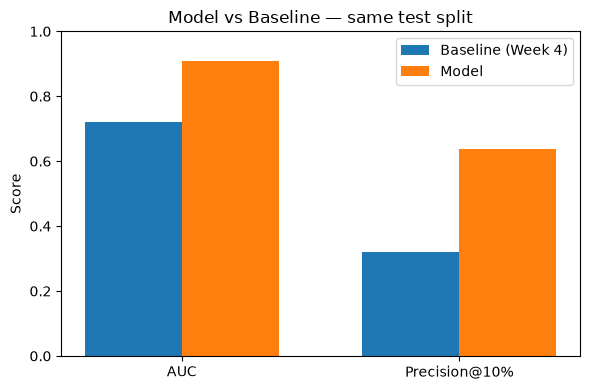

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def precision_at_k(y_true, scores, k_frac=0.10):
    n = len(y_true)
    k = int(n * k_frac)
    top_k_idx = np.argsort(scores)[::-1][:k]
    return y_true.iloc[top_k_idx].mean()

model_scores = model.predict_proba(X_test)[:, 1]
model_p10 = precision_at_k(y_test, model_scores, 0.10)
baseline_p10 = precision_at_k(y_test, baseline_score, 0.10)

results_table = pd.DataFrame({
    "Metric": ["AUC", "Precision@10%"],
    "Baseline (Week 4, visibility-only)": [baseline_auc, baseline_p10],
    "Model (HistGradientBoosting)": [model_auc, model_p10],
})
results_table["Improvement"] = results_table["Model (HistGradientBoosting)"] - results_table["Baseline (Week 4, visibility-only)"]
print(results_table)

# ---------- Chart for the paper ----------
fig, ax = plt.subplots(figsize=(6, 4))
metrics = ["AUC", "Precision@10%"]
baseline_vals = [baseline_auc, baseline_p10]
model_vals = [model_auc, model_p10]

x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, baseline_vals, width, label="Baseline (Week 4)")
ax.bar(x + width/2, model_vals, width, label="Model")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model vs Baseline — same test split")
ax.legend()
plt.tight_layout()

import os
os.makedirs("../../work/outputs", exist_ok=True)
plt.savefig("../../work/outputs/model_vs_baseline.png", dpi=150)
plt.show()

**Results, same held-out test set (13 clients, zero overlap with training):**

| Metric | Baseline (visibility-only) | Model | Improvement |
|---|---|---|---|
| AUC | 0.721 | 0.907 | +0.186 |
| Precision@10% | 0.321 | 0.638 | +0.317 |

The model outperforms the baseline on both metrics, and the gap is largest on Precision@10% — the metric that matters most for the actual decision this supports. On the same top-10% slice of pages an editor with limited bandwidth would realistically work through, the model nearly doubles the baseline's hit rate: roughly 64% of the model's top-ranked pages are genuinely declining, versus 32% for the visibility-only baseline. That's the difference between an editor's time being well spent roughly two-thirds of the time versus one-third.

## 5. Limitations

*What this work cannot claim.*

**What this work cannot claim:**

- **Not causal.** This model finds pages associated with future decline; it says nothing about why they decline, and a refresh recommendation is not a guarantee that refreshing will reverse the trend. No claim here proves or predicts Google's algorithm behavior.

- **Staleness signal dropped, not disproven.** Week 4 confirmed staleness as a real, useful signal — but `dim_content` reflects each page's current state rather than a true point-in-time snapshot, so a reliable "staleness as of February" couldn't be reconstructed without leaking future information. This model is weaker than it could be with proper historical staleness tracking.

- **Single month-pair tested.** The Feb→March split is one instance, not validated across multiple month-pairs or seasons. Performance could shift for a different pair of months, especially around seasonal content or year-end patterns.

- **Small client base.** Only 42 clients total, 13 in the held-out test set. Results are directional, not a guarantee of generalization to substantially different client types or industries outside this panel.

- **Arbitrary decline threshold.** The label (`March clicks < 80% of February clicks`) is a defensible but ultimately chosen cutoff. A different threshold would produce a different — not necessarily worse — set of "declining" pages.

- **Sparse engagement data.** As established in Week 3, GA4 coverage was only ~4% of rows in this slice; this model relies on Search Console signals alone rather than richer engagement data, which was largely unavailable.

All claims in this work are observed, directional, and decision-support — intended to guide where editorial attention goes, never a standalone or automated action.

In [8]:
print(f"Total clients in modeling data: {modeling_df['client_hash_id'].nunique()}")
print(f"Test-set clients: {len(test_clients)}")

Total clients in modeling data: 42
Test-set clients: 13


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [9]:
# ---------- Score every page in the modeling set with the trained model ----------
modeling_df["predicted_prob"] = model.predict_proba(modeling_df[feature_cols])[:, 1]

ranked_recommendations = modeling_df.sort_values("predicted_prob", ascending=False)[
    ["content_hash_id", "client_hash_id", "predicted_prob",
     "avg_position", "feb_clicks", "feb_impressions", "is_declining"]
].copy()

ranked_recommendations["action"] = ranked_recommendations["predicted_prob"].apply(
    lambda p: "refresh_priority" if p >= 0.7 else ("monitor" if p >= 0.4 else "no_action")
)
ranked_recommendations["reason_code"] = "predicted_decline_risk"

print(ranked_recommendations["action"].value_counts())
ranked_recommendations.head(10)

action
no_action           118075
monitor              13154
refresh_priority      3009
Name: count, dtype: int64


,content_hash_id,client_hash_id,predicted_prob,avg_position,feb_clicks,feb_impressions,is_declining,action,reason_code
33249,content_767c793957ee4c79,client_3f0ce4d44fe94f3d,0.98429,218.000000,1.0,1.0,1,refresh_priority,predicted_decline_risk
43883,content_6c67406260192162,client_f623b01661d4bfe4,0.98429,136.000000,1.0,2.0,1,refresh_priority,predicted_decline_risk
106412,content_89369045016063cc,client_08a6a72ff48e62c0,0.98429,63.562500,1.0,7.0,1,refresh_priority,predicted_decline_risk
3968,content_8e449ac0c94b13bf,client_3f0ce4d44fe94f3d,0.98429,76.250000,1.0,3.0,1,refresh_priority,predicted_decline_risk
57879,content_3685fe260329a832,client_f623b01661d4bfe4,0.98429,60.533333,1.0,7.0,1,refresh_priority,predicted_decline_risk
87924,content_b50aa9f1a96bdbde,client_3ffa76342f366962,0.98429,81.250000,1.0,3.0,1,refresh_priority,predicted_decline_risk
62145,content_b1143743073e3a2a,client_f623b01661d4bfe4,0.98429,100.500000,1.0,2.0,1,refresh_priority,predicted_decline_risk
131915,content_718ab3123d9e76d5,client_9958f0a7ae1df715,0.98429,58.200000,1.0,6.0,1,refresh_priority,predicted_decline_risk
98321,content_3f230cbfac13abd8,client_3f0ce4d44fe94f3d,0.98429,150.000000,1.0,1.0,1,refresh_priority,predicted_decline_risk
64666,content_e1d97f05713fe17a,client_3f0ce4d44fe94f3d,0.98429,85.125000,1.0,5.0,0,refresh_priority,predicted_decline_risk


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
